In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Ejercicio 1

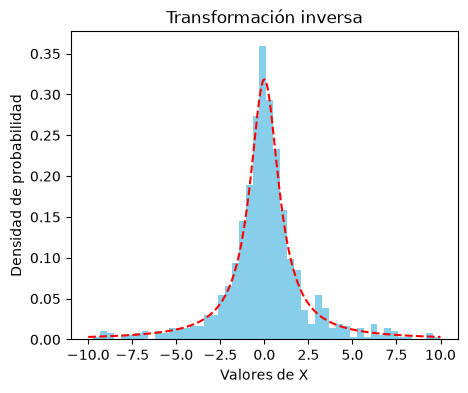

In [2]:
def f(x): #densidad de probabilidad
    return 1/np.pi*1/(1+x**2)

def transformacion_inv(N): #función acumulativa
    U = np.random.uniform(size= N)
    x = np.tan(np.pi*(U-0.5))
    return x

N=1_000
xf= np.linspace(-10,10,N)
datos= transformacion_inv(N)
datos_hist= datos[np.abs(datos) < 10] #Seleccionador booleano solo coge aquellos elementos del array que tienen el True
plt.figure(figsize=(5,4))
plt.hist(datos_hist, bins = 50, density= True, color= 'skyblue')
plt.plot(xf, f(xf), 'r--') #densidad de prob
plt.title("Transformación inversa")
plt.xlabel("Valores de X")
plt.ylabel("Densidad de probabilidad")
plt.show()

### Ejercicio 2

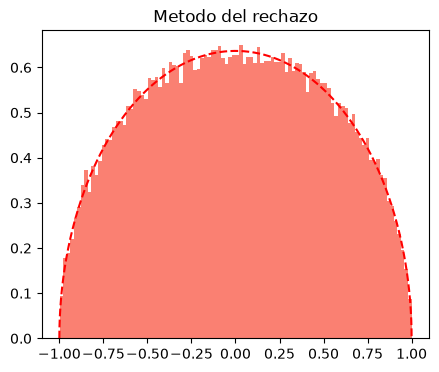

In [3]:
def fun(x):
    return (2/np.pi)*np.sqrt(1-x**2)

def g(x): #Tiene que ser una función de prob
    return 0.5

c= fun(0)/g(0) 

def rechazo(fun,g,c,N):
    sol=[]
    while len(sol)<N:
        U= np.random.rand()
        x_candidato= np.random.uniform(-1,1)
        if U < fun(x_candidato)/ (c*g(x_candidato)):
            sol.append(x_candidato)
    return sol
    
#Visualización
N=10**5
sol= rechazo(fun,g,c,N)
xf = np.linspace(-1,1,N)
plt.figure(figsize=(5,4))
plt.hist(sol, bins=100, density= True, color='salmon')
plt.plot(xf, fun(xf), 'r--')
plt.title("Metodo del rechazo")
plt.show()

### Ejercicio 3

Probabilidad de extinción: 0.01


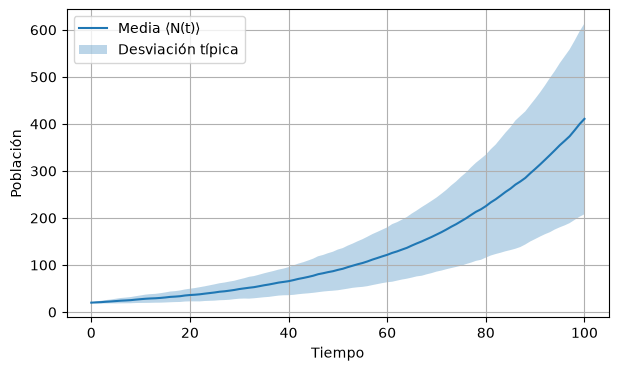

In [6]:
#Parametros
M= 100 #num de simulaciones
n= 0.1
m= 0.07
T_max=100
#Creamos la malla de tiempos
t_malla= np.linspace( 0, T_max, 101)
R = np.zeros((M, len(t_malla))) #Para las matrices recordar que lleva doble parentesis para que lo coja como 1 solo elemento
#Registros
extinciones=0
for i in range(M): #el comando range aqui se hace el contador solito
    N=20
    tiempos=[0.0]
    poblacion=[N]
#bucle
    t=0
    while t<T_max:
    #Caso de rotura de la cadena    
        if N==0:
            extinciones +=1
            break
    #Definimos prob
        Pn= n*N
        Pm= m*N
        PT= Pn +Pm
    #tiempos en los que ocurren, por teoría dist. exponencial
    #U1 y U2 son prob uniformes [0,1]
        U1= np.random.uniform()
        tau= 1/PT*np.log(1/U1)
        t= t+tau
    #Forma en la que ocurren los sucesos, cadena
        U2= np.random.uniform()
        prob_n= Pn/PT
        if U2 <= prob_n:
            N =N + 1
        else:
            N=N -1
    #Como en la suma de la ultima iteraccion puedo registrar un tiempo mayor al estimado tengo que poner un if
        if t < T_max:
            tiempos.append(t)
            poblacion.append(N)
    #Empezamos a interpolar los registros en la malla: tejemos
    # Asegurarse de que tiempos y poblacion tienen la misma longitud
    if len(tiempos) != len(poblacion): #importantísimo para la función de interpolar
        min_len = min(len(tiempos), len(poblacion))
        tiempos = tiempos[:min_len]
        poblacion = poblacion[:min_len]
    N_interpolado= np.interp(t_malla, tiempos, poblacion)
    R[i,:]= N_interpolado
#Medias y varianzas
Media_Nj= np.mean(R, axis=0)
Var_Nj= np.var(R, axis=0)
prob_ex = extinciones/M
print("Probabilidad de extinción:",prob_ex)

#Visualización
plt.figure(figsize=(7,4))
plt.plot(t_malla, Media_Nj, label="Media ⟨N(t)⟩")
plt.fill_between(t_malla, Media_Nj - np.sqrt(Var_Nj), Media_Nj + np.sqrt(Var_Nj), alpha=0.3, label="Desviación típica")
plt.xlabel("Tiempo")
plt.ylabel("Población")
plt.legend()
plt.grid()
plt.show()

### Ejercicio 4

Dendidad media: 0.9482833333333334
Energía media: -3.6984416666666666


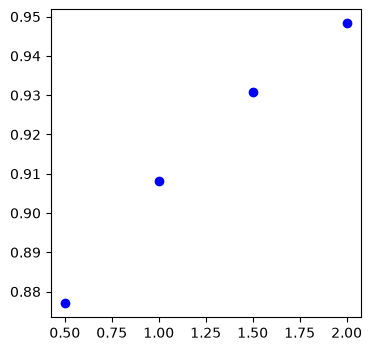

In [7]:
#PARAMETROS
MC= 500
L= 20
epsilon =1.0
mu= [0.5, 1, 1.5, 2]
T= 2 #Kelvin
beta= 1/T
termalizacion = 200 #pasos para llevar un poco al sistema al equilibrio

#VECINOS EN LA RED
def vecinos(i, j):
    return [((i+1)%L,j), ((i-1)%L,j), (i,(j+1)%L), (i,(j-1)%L)]

#VARIACIONES ENERGETICAS DEL CAMBIO
def delta_E(i,j, u):
    ni_viejo = red[i,j]
    ni_nuevo = 1- ni_viejo

    suma_vecinos = sum(red[x,y] for x, y in vecinos(i,j)) #np.sum y sum son dos comandos distintos, sum trabaja con generadores

    E_int= -epsilon*(ni_nuevo-ni_viejo)*suma_vecinos
    E_mu= u*(ni_nuevo-ni_viejo)
    E_tot= E_int- E_mu
    return E_tot

def energia_total(red, u):
    E = 0.0
    for i in range(L): #para recorrer la red en vez de con su matriz se hace con sus dimensiones
        for j in range(L):
            ni = red[i, j]
            # solo derecha y arriba para no duplicar enlaces
            nj_dcha = red[(i+1)%L, j] #Se hace asi porque tu recorres hacia un lado y luego hacia abajo de tal forma que
    #cuando estás en el sitio $i$, miras a tu vecino de la derecha, $j$. Sumas el término $-\epsilon (n_i n_j)$.
    #Más tarde, cuando el bucle llega al sitio $j$, miras a tu vecino de la izquierda, $i$. Vuelves a sumar el término, -epsilon (n_j n_i).
            nj_arr  = red[i, (j+1)%L]
            E -= epsilon * ni * (nj_dcha + nj_arr)
            E -= u * ni
    return E

#SE EMPIEZA MONTECARLO

rho_promedio= []
for u in mu:
    #ESTADO INICIAL
    red = np.random.randint(0,2,size= (L,L))
    densidad = [] #Si me da 0.0 o vacio es porque lo he metido dentro del bucle y se reinicia
    energias = []
    for paso in range(MC):
        for _ in range(L*L): # Para estimar que barre todo el gas al menos 1 vez
            i= np.random.randint(L)
            j= np.random.randint(L)

            dE = delta_E(i, j, u) 
            if dE<0 or np.random.rand() < np.exp(-beta*dE): #Lo segundo, es de una prob desfavorable si pasa el criterio se acepta
                red[i,j] = 1- red[i,j]
            
        if paso>= termalizacion:
            rho = np.mean(red)
            densidad.append(rho)
            E = energia_total(red, u)/(L*L)
            energias.append(E)
    rho_promedio.append(np.mean(densidad)) #Si es un vector 1D no tiene axis

print("Dendidad media:", np.mean(densidad))
print("Energía media:", np.mean(energias))

plt.figure(figsize= (4, 4))
plt.plot(mu,rho_promedio,'bo', label="Densidad promedio")
plt.show()

### Ejercicio 5

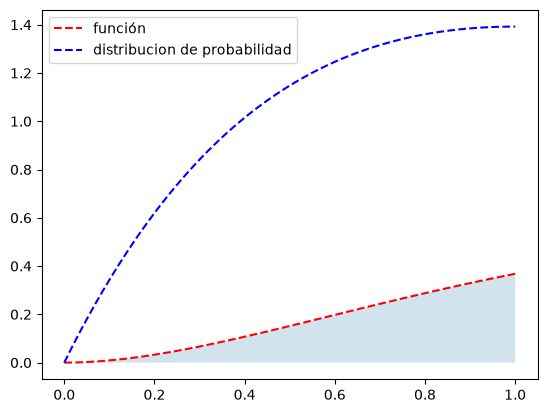

In [11]:
#Función a integrar
def f(x):
    return x**2*np.exp(-x)

def p(x):
    return (x*np.exp(-x))/(1-2*np.e**(-1))

I_exacto= 2- 5/np.e

#Intervalo [0,1]
a= 0
b= 1
x1= np.linspace(0,1,101) 
yf= f(x1)
#Muestras
N= [10**2, 10**3, 10**4, 10**5]

for n in N:
    U = np.random.uniform(size= n)
    y1= f(U)
    fi= np.mean(y1)
    I_cruda = (b-a)*fi
    

#Muestreo por importancia
p_max= np.max([p(x) for x in np.linspace(0,1,1000)])
for n in N:
    #U=np.random.uniform(size=n)
    muestras =[]
    while len(muestras)<n:
        U= np.random.rand()
        x= np.random.rand()*p_max 
        if x < p(U):
            muestras.append(U)
    X_m= np.array(muestras) 
    fi= np.mean(f(X_m)/p(X_m))
    I_m= fi
    

#Visualización
plt.figure()
plt.plot(x1, yf,'r--', label= "función")
plt.fill_between(x1, f(x1), alpha=0.2)
plt.plot(x1, p(x1), 'b--', label="distribucion de probabilidad")
plt.legend()
plt.show()